# 1. pynetrees basics

Load a neuron, look at it, measure it, draw it.

Everything here follows the conventions in
[`docs/concepts.md`](../docs/concepts.md): a tree is a flat list of nodes,
every per-node quantity is a NumPy array of length `n_nodes`, and functions
are named `verb_tree(tree, ...)` exactly as in the MATLAB TREES toolbox.

In [10]:
import numpy as np
import pynetrees as pt

tree = pt.sample_tree()   # a real 197-node reconstruction, bundled with the package
tree

Tree(name='sample', n_nodes=197, regions=[dendrite, subtree])

## The data model

A `Tree` is coordinates + diameters + regions + a parent pointer. Every array
below has one entry per node, all in the same order — so node `i`'s position is
`(X[i], Y[i], Z[i])`, its diameter is `D[i]`, and so on.

In [2]:
print(f"nodes    : {tree.n_nodes}")
print(f"X, Y, Z  : {tree.X.shape}, {tree.Y.shape}, {tree.Z.shape}")
print(f"diameters: {tree.D.min():.2f} - {tree.D.max():.2f} um")
print(f"regions  : {tree.rnames}")
print(f"dA       : {tree.dA.shape} sparse, {tree.dA.nnz} edges")

nodes    : 197
X, Y, Z  : (197,), (197,), (197,)
diameters: 1.30 - 4.30 um
regions  : ['dendrite', 'subtree']
dA       : (197, 197) sparse, 196 edges


`dA` is the topology: `dA[i, j] == 1` means *j is i's parent*. You rarely touch
it directly — `idpar_tree` gives the same information as a plain array, which is
what you actually want to compute with.

In [3]:
parent = pt.idpar_tree(tree)
print("parent of node 5 :", parent[5])
print("parent of root   :", parent[0], "(the root is its own parent by default)")

# ...or an explicit -1 sentinel instead, if you're walking upwards in a loop
parent_strict = pt.idpar_tree(tree, root_self=False)
print("root, strict     :", parent_strict[0], "== pt.NO_PARENT")

parent of node 5 : 4
parent of root   : 0 (the root is its own parent by default)
root, strict     : -1 == pt.NO_PARENT


## Health check

Real reconstructions are often not *BCT-conform* (strictly binary, no
zero-length segments, parents before children). `validate()` reports problems
without raising — a tree can legitimately be half-built mid-pipeline.

In [4]:
issues = tree.validate()
print("problems:", issues if issues else "none - tree is well formed")

# repair_tree fixes them; it is a no-op on an already-clean tree, so calling it
# unconditionally after loading unknown data is the safe default
tree = pt.repair_tree(tree)
print("after repair_tree:", tree)

problems: none - tree is well formed
after repair_tree: Tree(name='sample', n_nodes=197, regions=[dendrite, subtree])


## Measuring

These all return one value per node. Because they're plain arrays, combining
them is just NumPy.

In [5]:
length = pt.len_tree(tree)          # segment length [um]
surf   = pt.surf_tree(tree)         # segment surface area [um^2]
eucl   = pt.eucl_tree(tree)         # straight-line distance to the root [um]
plen   = pt.Pvec_tree(tree, length) # metric path length along the tree [um]
order  = pt.BO_tree(tree)           # branch order

print(f"total length      : {length.sum():8.1f} um")
print(f"total surface     : {surf.sum():8.1f} um^2")
print(f"furthest tip      : {plen.max():8.1f} um along the tree")
print(f"                    {eucl.max():8.1f} um in a straight line")
print(f"max branch order  : {order.max():8.0f}")

total length      :    765.2 um
total surface     :   3836.5 um^2
furthest tip      :    142.7 um along the tree
                       119.0 um in a straight line
max branch order  :        9


`Pvec_tree` is the general "accumulate along the path to the root" operation —
pass it *any* per-node vector, not just lengths.

Node-type masks are booleans, so they slice other arrays directly:

In [6]:
terminals = pt.T_tree(tree)   # mask: is this node a tip?
branches  = pt.B_tree(tree)   # mask: is this node a branch point?

print(f"{terminals.sum()} terminals, {branches.sum()} branch points")
print(f"mean path length to a tip: {plen[terminals].mean():.1f} um")

# tortuosity: how much longer is the path than the straight line?
tortuosity = plen[terminals] / eucl[terminals]
print(f"mean tip tortuosity      : {tortuosity.mean():.3f}")

26 terminals, 25 branch points
mean path length to a tip: 118.0 um
mean tip tortuosity      : 1.193


## Selecting parts of a tree

By region (this replaces the MATLAB `find(tree.R == find(strcmp(...)))` idiom):

In [7]:
# the bundled sample has two simple, generic regions -- see notebook 05 for a
# granule cell with proper soma / axon / dendritic-layer regions
print("regions:", tree.rnames)
first_region = tree.rnames[0]
print(f"nodes in {first_region!r}:", tree.region_nodes(first_region)[:8], "...")

# asking for a region that doesn't exist fails loudly, listing what IS available.
# MATLAB's find(strcmp(...)) silently returns empty here, so the *next* line
# quietly matches nothing instead of telling you the name was wrong.
try:
    tree.region_nodes("soma")
except KeyError as e:
    print("\nKeyError:", e)

regions: ['dendrite', 'subtree']
nodes in 'dendrite': [0 1 2 3 4 5 6 7] ...

KeyError: "no region 'soma' in tree 'sample'; available regions: ['dendrite', 'subtree']"


By subtree, and by section (the stretches between branch points — the natural
unit for compartmental modelling):

In [8]:
node = int(np.flatnonzero(branches)[0])
sub = pt.sub_tree(tree, node)
print(f"subtree below node {node}: {sub.mask.sum()} nodes")

sections = pt.dissect_tree(tree)
print(f"tree splits into {len(sections)} sections")
print("first few (start, end) node pairs:")
print(sections[:5])

subtree below node 2: 195 nodes
tree splits into 51 sections
first few (start, end) node pairs:
[[ 0  2]
 [ 2  4]
 [ 4  5]
 [ 4  7]
 [ 7 13]]


## Plotting

`plot_tree` renders in 3D via PyVista. `scalars=` accepts any per-node array,
so you can colour by any measurement you just computed.

Nothing plots as a side effect anywhere in pynetrees — MATLAB's `'-s'` show
option is gone, which is why colouring by an arbitrary quantity is this easy.

In [17]:
import pyvista as pv
pv.set_jupyter_backend("trame")  # <-- change to "trame" for live widgets


In [9]:
plotter = pt.plot_tree(tree, scalars=order.astype(float), cmap="viridis", mode="tube")
plotter.add_text("coloured by branch order", font_size=10)
plotter.camera_position = "xy"
plotter.show()

Widget(value='<iframe src="http://localhost:49720/index.html?ui=P_0x20a3f279550_0&reconnect=auto" class="pyvis…

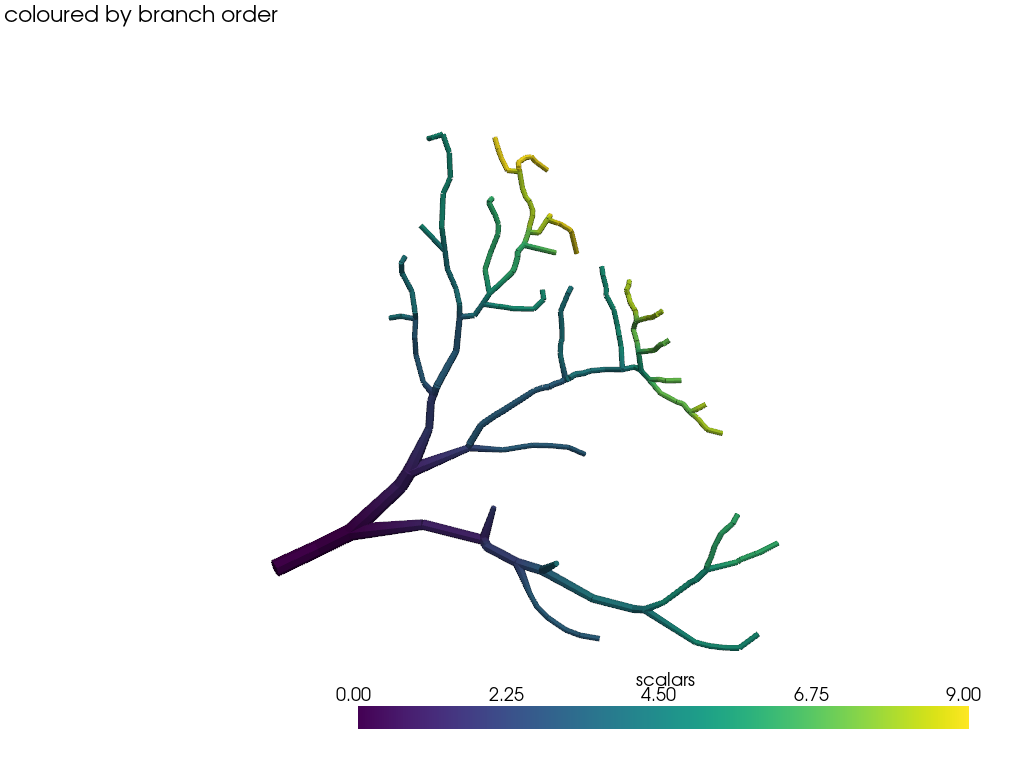

In [12]:
plotter = pt.plot_tree(tree, scalars=order.astype(float), cmap="viridis", mode="tube")
plotter.add_text("coloured by branch order", font_size=10)
plotter.camera_position = "xy"
plotter.screenshot("tut01_branch_order.png")
plotter.close()

from IPython.display import Image
Image("tut01_branch_order.png")

Use `mode="line"` instead of `"tube"` when you have many cells or a very large
tree — it skips building the radius-varying tube mesh and is far faster.

For a live, rotatable widget rather than a static image, see
[`plot.ipynb`](plot.ipynb), which covers PyVista's `trame` Jupyter backend.

**Next:** [`02_editing_and_construction.ipynb`](02_editing_and_construction.ipynb)